# Dataset Creation for Mountain NER 

In [1]:
## install required dependencies from the root directory.
# uncomment and run this cell if you prefer to set up the environment directly from this notebook.

# %pip install -r ../requirements.txt

In [2]:
from dotenv import load_dotenv, find_dotenv
import os
import google.genai as genai
import json
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
from matplotlib_venn import venn2, venn3
import random

In [3]:
load_dotenv(find_dotenv())
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

In [4]:
OUTPUT_FILE = "../data/raw/ner_dataset.json"
TRAIN_FILE = "../data/processed/train.json"
VALID_FILE = "../data/processed/valid.json"
TEST_FILE = "../data/processed/test.json"
MODEL = 'gemini-3.6-flash'
TARGET_DATASET_SIZE = 2000
HARD_NEGATIVES_THRESHOLD = int(TARGET_DATASET_SIZE * 0.2)  

client = genai.Client(api_key=GOOGLE_API_KEY)
prompts_dict = {
    "initial": """
        Act as a Data Engineer creating a dataset for an NLP Named Entity Recognition (NER) task. 
        Generate 50 NEW and UNIQUE English sentences describing expeditions, tourism,scientific research, or geography. 

        Rules:
        1. Each sentence MUST contain exactly one name of a prominent mountain.
        2. Mix the naming styles: sometimes use the "Mount X" format, sometimes use the mountain name directly.
        3. Vary the position of the mountain name.
        4. Include various surrounding geographical features (tagged as "O").
        5. Only the mountain name should be tagged as "B-MOUNTAIN" / "I-MOUNTAIN".
        6. Provide the output in a STRICT JSON array format.
        7. Do not include markdown formatting like ```json in the output.
        8. Each object must have "tokens" (list of string words/punctuation) and "ner_tags" (list of BIO tags).
        
        Example:
        [
            {
                "tokens": ["Mount", "Fuji", "overlooks", "the", "Bay", "."],
                "ner_tags": ["B-MOUNTAIN", "I-MOUNTAIN", "O", "O", "O", "O"]
            }
        ]
    """,
    
    "positive_batch": """
        Act as a Data Engineer creating a dataset for an NLP Named Entity Recognition (NER) task. 
        Generate 50 NEW and UNIQUE English sentences describing expeditions, tourism,scientific research, or geography. 
    
        IMPORTANT: You have already generated {num_existing} sentences previously. 
        Do NOT repeat previous ideas. Use different contexts and a variety of mountain names.
    
        Rules:
        1. Each sentence MUST contain exactly one name of a prominent mountain from anywhere in the world (e.g., Alps, Andes, Rockies, Caucasus, Himalayas).
        2. Crucially, mix the naming styles: sometimes use the "Mount X" format (e.g., Mount Blanc), and sometimes use the mountain name directly without any prefix (e.g., Everest, Hoverla, Kilimanjaro).
        3. Vary the position of the mountain name: place it at the beginning, in the middle, or at the end of sentences across different examples.
        4. In many sentences, include various surrounding geographical features (e.g., provinces, nearby straits, valleys, rivers, bays, or borders).
        5. Only the mountain name should be tagged as "B-MOUNTAIN" / "I-MOUNTAIN". ALL other geographical entities MUST be tagged as "O".
        6. Provide the output in a STRICT JSON array format.
        7. Do not include markdown formatting like ```json in the output, just the raw JSON array.
        8. Each object must have "tokens" (list of string words/punctuation) and "ner_tags" (list of BIO tags).
    """,
    
    "hard_negatives": """
        Act as a Data Engineer creating a dataset for an NLP Named Entity Recognition (NER) task. 
        Generate 50 UNIQUE English sentences designed as "Hard Negatives" to prevent the model from overgeneralizing.
                
        Split the 50 sentences equally into FIVE categories (10 sentences each):
                
        CATEGORY 1: Non-geographical use of mountain names (brands, pet names, human names, companies).
        Example: "He named his dog Everest."
                
        CATEGORY 2: Other geographical entities (cities, countries, rivers, oceans, straits).
        Example: "The Bosphorus strait connects to the Black Sea."
                
        CATEGORY 3: Wordplay and common nouns. Use words like "mount", "mountain", "peak", or "summit" as regular verbs or metaphorical nouns.
        Example: "We need to mount the new TV on the wall." or "She reached the peak of her career."
                
        CATEGORY 4: Deceptive names. Use locations, universities, or media titles that contain the word "Mount" or "Mountain" but are NOT actual mountains.
        Example: "Google's office is in Mountain View." or "I watched Brokeback Mountain."
                
        CATEGORY 5: Other physical landforms. Use famous canyons, plateaus, hills, cliffs, or deserts.
        Example: "Tourists love the Grand Canyon and the Cliffs of Moher."
                
        Rules:
        1. VERY IMPORTANT: Because there are NO actual mountains acting as mountains in these sentences, their ner_tags MUST be completely "O". Do NOT use "B-MOUNTAIN" or "I-MOUNTAIN" anywhere.
        2. Provide the output in a STRICT JSON array format.
        3. Do not include markdown formatting like ```json in the output, just the raw JSON array.
        4. Each object must have "tokens" (list of string words/punctuation) and "ner_tags" (list of BIO tags).
    """
}

## Data Loading and Generation

In [5]:
def load_existing_data(output_file):
    '''
        Loads previously generated data from a JSON file. 
        This allows the script to resume generation without losing progress.
    '''
    existing_data = []
    if os.path.exists(output_file):
        with open(output_file, "r", encoding="utf-8") as f:
            existing_data = json.load(f)
        return existing_data
    else:
        print("Output file hasn't been created yet")
        return []
def generate_batch(prompt):
    '''
        Generates a batch of sentences based on the provided prompt using the Google Gemini API.
        It handles the response, ensuring that the output is a valid JSON array and returns it.
    '''
    try:
        response = client.models.generate_content(
            model=MODEL,
            contents=prompt
        )
        raw_text = response.text.strip()
    
        if raw_text.startswith("```json"):
            raw_text = raw_text[7:]
        if raw_text.endswith("```"):
            raw_text = raw_text[:-3]
    
        raw_text = raw_text.strip()
        new_data = json.loads(raw_text)
    
        if isinstance(new_data, list): 
            print(f"{len(new_data)} sentences successfully generated")
            return new_data
        else:
            print("Error: the generated content is not a valid JSON array")
            return []
            
    except Exception as e:
        print(f"Error: {e}")
        return []

existing_data = load_existing_data(OUTPUT_FILE)

## checks the current dataset size, selects the appropriate prompt (initial, positive, or hard negative), 
## generates a new batch of sentences, and immediately saves the progress to the file until the 
## TARGET_DATASET_SIZE is reached.

while len(existing_data) < TARGET_DATASET_SIZE:
    num_existing = len(existing_data)
    
    if num_existing == 0:
        prompt = prompts_dict["initial"]
    elif num_existing > HARD_NEGATIVES_THRESHOLD:
        prompt = prompts_dict["positive_batch"].format(num_existing=num_existing)
    else:
        prompt = prompts_dict["hard_negatives"].format(num_existing=num_existing)

    batch = generate_batch(prompt)
    if len(batch) != 0:
        remaining_needed = TARGET_DATASET_SIZE - len(existing_data)

        if remaining_needed < 50:
            batch = batch[:remaining_needed]

        existing_data.extend(batch)
        with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
            json.dump(existing_data, f, indent=4, ensure_ascii=False)

    time.sleep(15)

## Label AND Duplication Validation

In [6]:
## uncomment the following line to load existing data for validation if you have already generated the dataset and want to validate it
# existing_data = load_existing_data(OUTPUT_FILE)

## ensure that every sentence has an equal number of tokens and NER tags, and that no illegal tags were generated by the LLM.
valid_data = []
valid_tags = {'O', 'B-MOUNTAIN', 'I-MOUNTAIN'}
corrupted_count = 0

for i, item in enumerate(existing_data):
    tokens = item.get("tokens", [])
    ner_tags = item.get("ner_tags", [])
    
    if len(tokens)!= len(ner_tags):
        print(f"Corrupted entry at index {i}: mismatched lengths, tokens: {len(tokens)}, NER tags: {len(ner_tags)}")
        corrupted_count += 1
        continue
    
    if not all(tag in valid_tags for tag in ner_tags):
        print(f"Corrupted entry at index {i}: invalid NER tags found")
        corrupted_count += 1
        continue
    
    valid_data.append(item)

print(f"Label validation complete: {len(valid_data)} valid sentences, {corrupted_count} corrupted entries removed")

# ensure that every sentence is unique by dropping exact duplicates based on tokens
df = pd.DataFrame(valid_data)
df = df[~df['tokens'].apply(tuple).duplicated()]
print(f"Duplication validation complete: {len(df)} valid entries")

with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(df.to_dict(orient="records"), f, indent=4, ensure_ascii=False)

Label validation complete: 2000 valid sentences, 0 corrupted entries removed
Duplication validation complete: 2000 valid entries


## Exploratory Data Analysis (EDA)

> **⚠️ Important:** 
> Before proceeding with the EDA, please ensure that:
> the dataset file (`ner_dataset_valid.json`) is placed in the `../data/processed/` folder.
> OR the **Label Validation** section has been executed to verify that all tags and alignment are correct.

Normal sentences (with mountains): 80.75%
Hard negative sentences (without mountains): 19.25%


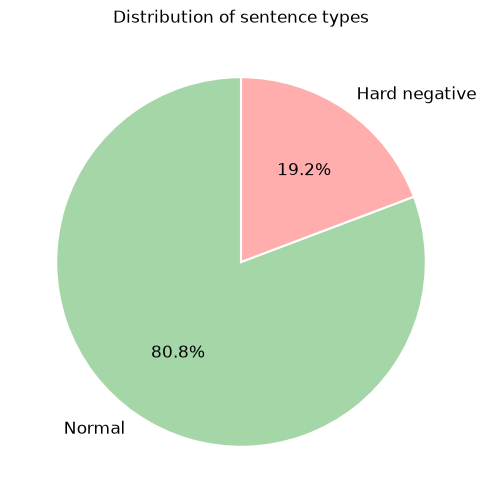

In [7]:
## analyze the distribution of sentence type, lengths and the frequency of unique mountain entities to understand our dataset's diversity
## uncomment the following lines if you have already validated the dataset and want to analyze it without re-running the validation step
# load_existing_data(OUTPUT_FILE)
# df = pd.DataFrame(valid_data)

## analyze the distribution of sentence type
df['is_hard_negative'] = df['ner_tags'].apply(lambda tags: "B-MOUNTAIN" not in tags)
distribution = df['is_hard_negative'].value_counts(normalize=True)
normal_percent = distribution.get(False, 0)
hard_negative_percent = distribution.get(True, 0)
print(f"Normal sentences (with mountains): {normal_percent:.2%}")
print(f"Hard negative sentences (without mountains): {hard_negative_percent:.2%}")

labels = ['Normal', 'Hard negative']
sizes = [normal_percent, hard_negative_percent]

plt.figure(figsize=(6, 6))
plt.pie(
    sizes, 
    labels=labels,
    autopct='%1.1f%%', 
    startangle=90, 
    colors=["#A5D6A7", "#FFADAD"], 
    textprops={'color': 'black', 'fontsize': 12, 'weight': '400'}, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title('Distribution of sentence types')
plt.show()

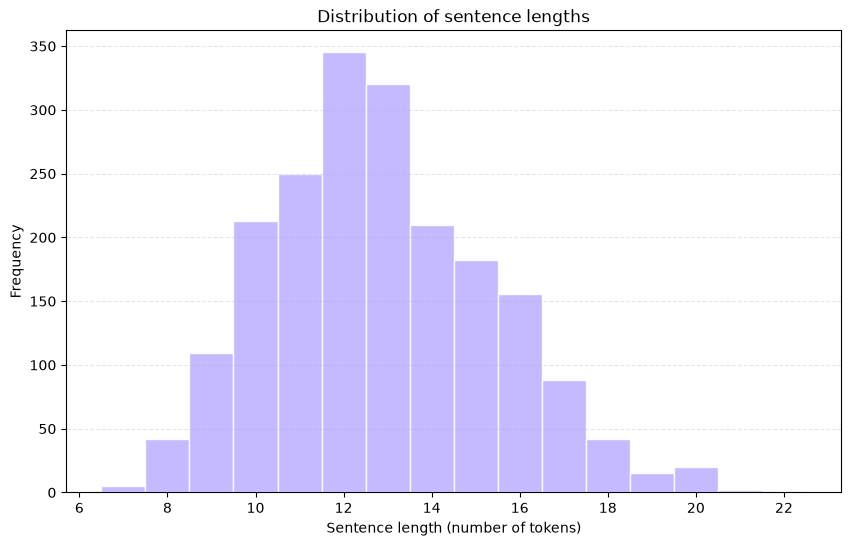

In [8]:
## analyze the distribution of sentence lengths
df['sentence_length'] = df['tokens'].apply(len)

min_len = df['sentence_length'].min()
max_len = df['sentence_length'].max()
exact_bins = np.arange(min_len - 0.5, max_len + 1.5, 1)

plt.figure(figsize=(10, 6))
plt.hist(df['sentence_length'], bins=exact_bins, color="#BFB2FF", edgecolor='white', alpha=0.9)
plt.title('Distribution of sentence lengths')
plt.xlabel('Sentence length (number of tokens)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


Total unique mountains found: 192


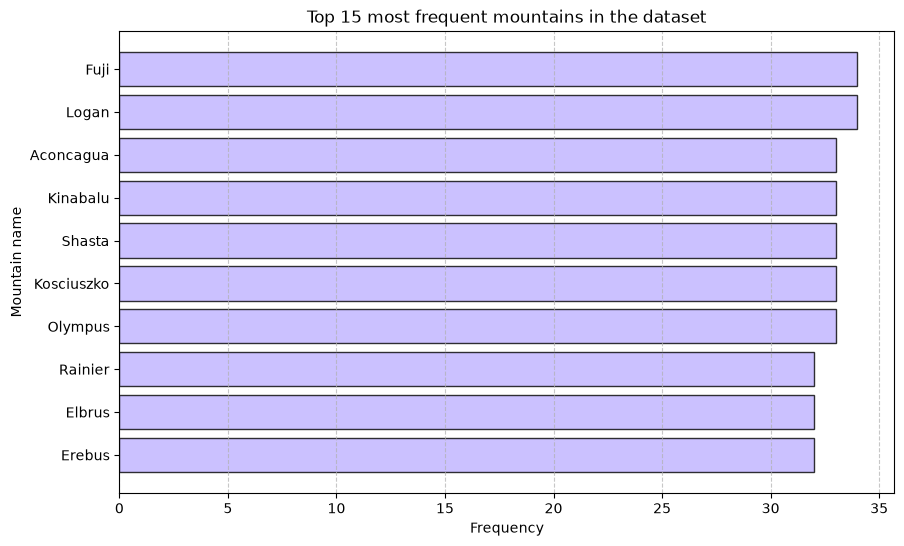

In [9]:
## analyze the distribution of the frequency of unique mountain entities
def extract_mountain_names(df):
    '''
        Extracts unique mountain names from the valid dataset and counts their occurrences
    '''
    all_mountains = []
    ignore_prefixes = {'mount', 'mt', 'mt.'}

    def _clean_mountain_name(tokens):
        '''
            Cleans the mountain name by removing any leading prefixes like "Mount", "Mt", or "Mt."
        '''
        if not tokens:
            return None
        if tokens[0].lower() in ignore_prefixes:
            tokens = tokens[1:]
                    
        if tokens:
            return " ".join(tokens)
        return None

    for index, row in df.iterrows():
        tokens = row['tokens']
        ner_tags = row['ner_tags']

        current_mountain = []
            
        for token, tag in zip(tokens, ner_tags):
            if tag == "B-MOUNTAIN":
                ## if we were already collecting a mountain name, save it before starting a new one
                if current_mountain:
                    cleaned_token =_clean_mountain_name(current_mountain)
                    if cleaned_token: 
                        all_mountains.append([index, cleaned_token])
                current_mountain = [token]

            elif tag == "I-MOUNTAIN" and current_mountain:
                current_mountain.append(token)

            else:
                cleaned_token =_clean_mountain_name(current_mountain)
                if cleaned_token:
                    all_mountains.append([index, cleaned_token])
                current_mountain = []

    ## handle any remaining mountain name at the end of the sentence
    cleaned_name = _clean_mountain_name(current_mountain)
    if cleaned_name:
        all_mountains.append([index, cleaned_name])

    return all_mountains

normal_df = df[~df['is_hard_negative']].reset_index(drop=True)
hard_df = df[df['is_hard_negative']].reset_index(drop=True)
extracted_mountains = np.array(extract_mountain_names(normal_df))
mountain_counts = Counter(extracted_mountains[:, 1])
print(f"\nTotal unique mountains found: {len(mountain_counts)}")

top_10_entities = mountain_counts.most_common(10)
if top_10_entities:
    mountains, counts = zip(*top_10_entities)
    display_mountains = [m.title() for m in mountains]

    plt.figure(figsize=(10, 6))
    plt.barh(display_mountains, counts, color="#BFB2FF", edgecolor='black', alpha=0.8)
    plt.title("Top 15 most frequent mountains in the dataset")
    plt.xlabel("Frequency")
    plt.ylabel("Mountain name")
    plt.gca().invert_yaxis() 
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

### Lexical Overlap Analysis
In this section, analyze the vocabulary intersection to evaluate the quality and complexity of the generated dataset.

1. Global lexical overlap
This compares the entire vocabulary of normal sentences with hard negative sentences. A massive overlap (including stop-words and common verbs) is expected and serves as a positive indicator. It proves that the generated hard negatives maintain a natural English sentence structure and share the same general domain context, rather than being isolated or unnatural text.

2. Entity overlap 
Here, comparing the extracted mountain entity tokens against the entire hard negative vocabulary. Since actual mountains don't exist in the hard negative subset, this overlap highlights "chameleon" words (e.g., "Everest" used as a pet's name). The presence of these tokens ensures the NER model is forced to learn syntactic context instead of simply memorizing a static dictionary of mountain names.

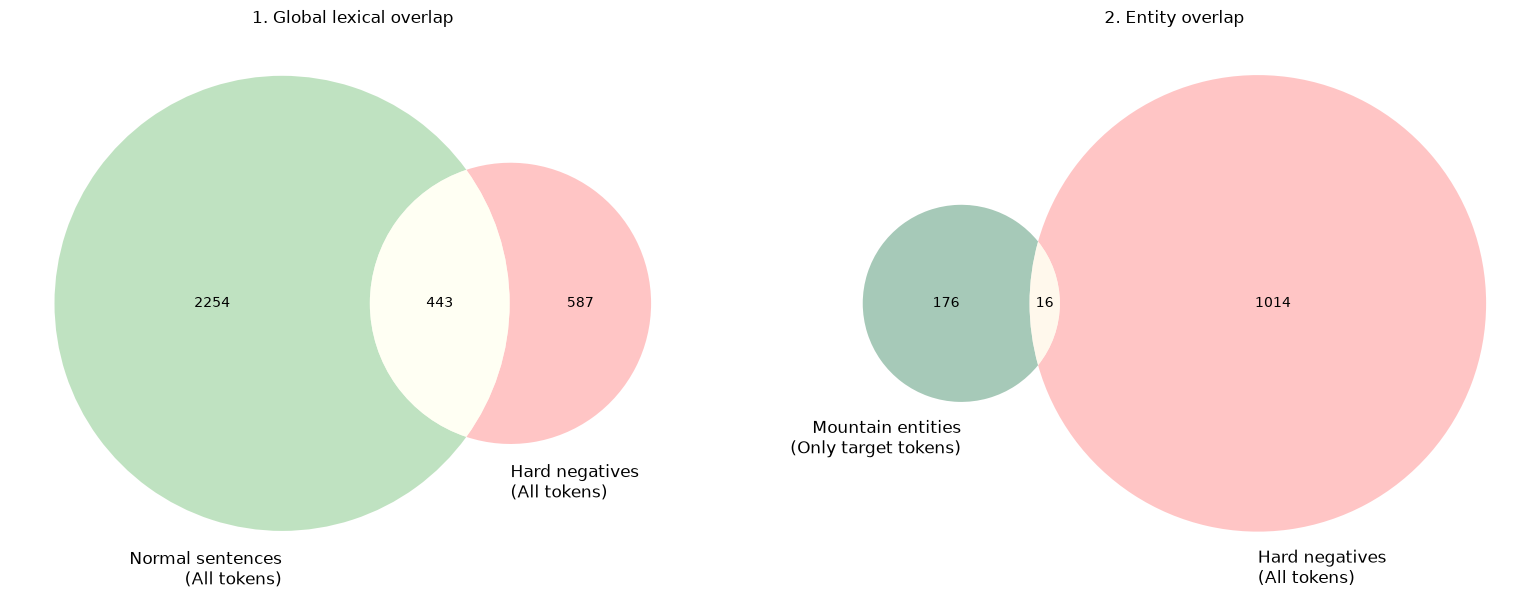

In [10]:
## analyze lexical overlap between normal sentences and hard negatives to ensure that the model is not overfitting to specific words or phrases
## IMPORTANT: This analysis is only meaningful if the dataset contains both normal sentences and hard negatives. If the dataset is skewed towards one type, the overlap analysis may not provide useful insights.
positive_entity_tokens = {mountain.lower() for mountain in extracted_mountains[:, 1]}
normal_tokens = set(df[df['is_hard_negative'] == False]['tokens'].explode().str.lower())
hard_negative_tokens = set(df[df['is_hard_negative'] == True]['tokens'].explode().str.lower())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

## global lexical overlap
venn1 = venn2(
    subsets=[normal_tokens, hard_negative_tokens], 
    set_labels=('Normal sentences\n(All tokens)', 'Hard negatives\n(All tokens)'),
    set_colors=("#A5D6A7", "#FFADAD"), 
    alpha=0.7,
    ax=axes[0] 
)
axes[0].set_title("1. Global lexical overlap")

## entity overlap 
venn2_plot = venn2(
    subsets=[positive_entity_tokens, hard_negative_tokens], 
    set_labels=('Mountain entities\n(Only target tokens)', 'Hard negatives\n(All tokens)'),
    set_colors=("#81b29a","#FFADAD"),
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("2. Entity overlap")
plt.tight_layout()
plt.show()


In [ ]:
## hard negatives don't contain actual mountain entities, so we can simply split them sequentially 
## without worrying about entity leakage
hard_total = len(hard_df)
hard_test_size, hard_valid_size = int(hard_total * 0.1), int(hard_total * 0.1)

hard_df['split'] = 'train'
hard_df.loc[:hard_test_size - 1, 'split'] = 'test'
hard_df.loc[hard_test_size:(hard_test_size + hard_valid_size - 1), 'split'] = 'valid'

## calculate the target number of sentences for 10% test and 10% valid splits
normal_total = len(normal_df)
normal_test_size, normal_valid_size = int(normal_total * 0.1), int(normal_total * 0.1)
normal_train_size = normal_total - normal_test_size - normal_valid_size 

## sort mountains by frequency in ASCENDING order (rarest first)
unique_mountains = sorted(mountain_counts.items(), key=lambda x: x[1])

## packing smaller groups first makes it easier to hit the exact target sizes
mountain_to_split = {}
current_test_size = 0
current_valid_size = 0

for mountain, count in unique_mountains:
    available_splits = [] 
    
    if current_test_size + count <= normal_test_size:
        available_splits.append('test')
        
    if current_valid_size + count <= normal_valid_size:
        available_splits.append('valid')

    ## if there is space, randomly assign the mountain to one of the available splits
    if available_splits:
        chosen_split = random.choice(available_splits)
        mountain_to_split[mountain] = chosen_split
        
        if chosen_split == 'test':
            current_test_size += count
        else:
            current_valid_size += count
            
    else:
        mountain_to_split[mountain] = 'train'

normal_df['split'] = 'train' 

for item in extracted_mountains:
    idx = int(item[0]) 
    mountain = item[1]
    
    normal_df.loc[idx, 'split'] = mountain_to_split.get(mountain, 'train')

## concatenate both dataframes, drop any accidental NaNs, and reset indices
final_df = pd.concat([normal_df, hard_df]).dropna(subset=['tokens']).reset_index(drop=True)
## verify the final distribution
print(final_df['split'].value_counts())


split
train    1614
test      194
valid     192
Name: count, dtype: int64


In [ ]:
train_df = final_df[final_df['split'] == 'train']
valid_df = final_df[final_df['split'] == 'valid']
test_df = final_df[final_df['split'] == 'test']

## dropp unnecessary columns 
train_df.drop(columns=['split', 'is_hard_negative', 'sentence_length'], errors='ignore').to_dict(orient='records')

## write samples in the files
with open(TRAIN_FILE, "w", encoding="utf-8") as f:
    json.dump(train_df.drop(columns=['split', 'is_hard_negative', 'sentence_length'], errors='ignore').to_dict(orient='records'), f, indent=4, ensure_ascii=False)

with open(VALID_FILE, "w", encoding="utf-8") as f:
    json.dump(valid_df.drop(columns=['split', 'is_hard_negative', 'sentence_length'], errors='ignore').to_dict(orient='records'), f, indent=4, ensure_ascii=False)

with open(TEST_FILE, "w", encoding="utf-8") as f:
    json.dump(test_df.drop(columns=['split', 'is_hard_negative', 'sentence_length'], errors='ignore').to_dict(orient='records'), f, indent=4, ensure_ascii=False)

Unique mountains in Train: 61
Unique mountains in Valid: 74
Unique mountains in Test:  57


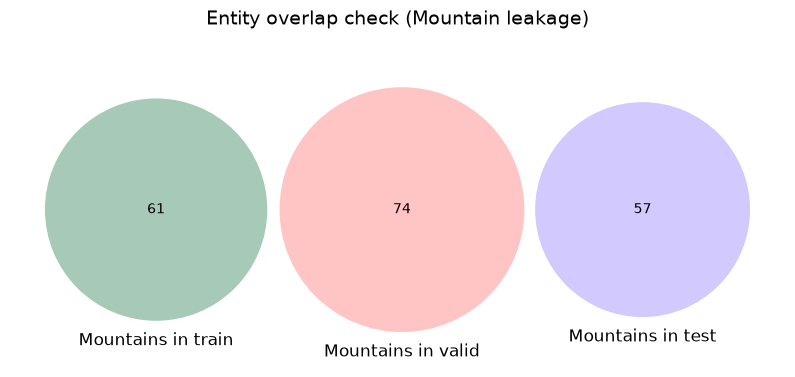

In [ ]:
## extract mountains from the final splits to definitively prove there is zero entity data leakage. the computational cost for ~2000 rows is insignificant.
train_mountain = {mountain.lower() for mountain in np.array(extract_mountain_names(train_df))[:, 1]}
valid_mountain = {mountain.lower() for mountain in np.array(extract_mountain_names(valid_df))[:, 1]}
test_mountain = {mountain.lower() for mountain in np.array(extract_mountain_names(test_df))[:, 1]}

## entity overlap check 
plt.figure(figsize=(10, 6))
venn3_plot = venn3(
    subsets=[train_mountain, valid_mountain, test_mountain], 
    set_labels=('Mountains in train', 'Mountains in valid', 'Mountains in test'),
    set_colors=("#81b29a","#FFADAD", "#BFB2FF"),
    alpha=0.7,
)
plt.title('Entity overlap check (Mountain leakage)', fontsize=14, pad=20)
plt.show()